# Supplemental Figure 6 and 7 - Epistasis heatmaps for each phenotype 

This script plots epistasis heatmaps for each phenotype and for each framework (Supplemental Figure 6 is for the reference-based framework and Supplemental Figure 7 is for the reference-free framework) Each figure displays a heatmap for additive coefficients, pairwise (second-order) coefficients, and the absolute sum of all higher order coefficients that each Omi32 mutation is involved in.

- Additive and pairwise coefficients are only colored if they are significant by bonferroni-corrected p-value
- For higher-order absolute sums, a coefficient is only included in the absolute sum if it is significant by bonferroni-corrected p-value
- the base p-value requirement for significance is 0.05, so the bonferroni-corrected p-value must be below 0.05 divided by the number of coefficients inferred for each model in order for an individual coefficient to be considered significant (this is calculated during the epistasis inference in `epistasis_inference/linear_interaction_models` for each phenotype)

In [2]:
import os
import csv
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.ticker as ticker

**Supplemental Figure 6 - reference-based framework (all panels)**

Loading data and printing value ranges...

Wuhan affinity  (R²=0.814, sig coefs=29)
  First-order  range: [-0.2652, 1.6607]
  Second-order range: [-0.4139, 0.2776]
  Higher-order: none

BA.1 affinity  (R²=0.823, sig coefs=37)
  First-order  range: [-0.5307, 1.6377]
  Second-order range: [-0.8474, 0.3639]
  Higher sums  range: [0.1270, 2.4065]

BA.4 affinity  (R²=0.880, sig coefs=42)
  First-order  range: [0.0000, 0.7885]
  Second-order range: [-0.2147, 0.7475]
  Higher sums  range: [0.2490, 3.3382]

expression  (R²=0.346, sig coefs=24)
  First-order  range: [-0.2038, 0.1056]
  Second-order range: [-0.1210, 0.1332]
  Higher-order: none

polyspecificity  (R²=0.364, sig coefs=8)
  First-order  range: [-0.5150, 0.0000]
  Second-order range: [-0.1512, 0.4297]
  Higher-order: none

Plotting (one figure per phenotype)...

→ Wuhan affinity


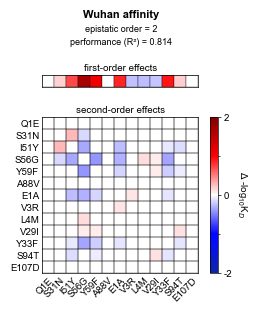

  Saved: S_Figure_6/wuhan_affinity_S_Figure_6.png
  Figure size: 2.755 × 3.180 in  |  canvas: 1.560 × 1.980 in

→ BA.1 affinity


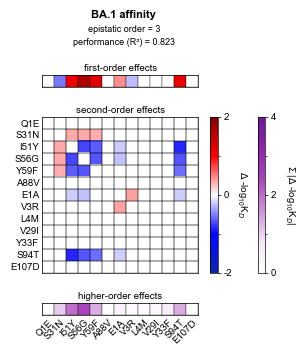

  Saved: S_Figure_6/ba1_affinity_S_Figure_6.png
  Figure size: 3.230 × 3.600 in  |  canvas: 1.560 × 2.400 in

→ BA.4 affinity


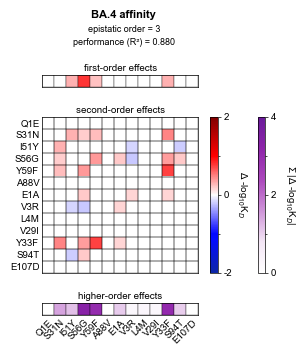

  Saved: S_Figure_6/ba4_affinity_S_Figure_6.png
  Figure size: 3.230 × 3.600 in  |  canvas: 1.560 × 2.400 in

→ expression


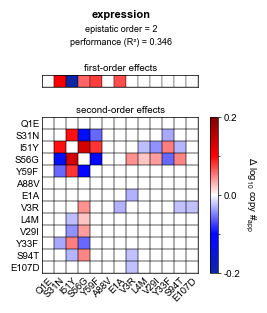

  Saved: S_Figure_6/expression_S_Figure_6.png
  Figure size: 2.755 × 3.180 in  |  canvas: 1.560 × 1.980 in

→ polyspecificity


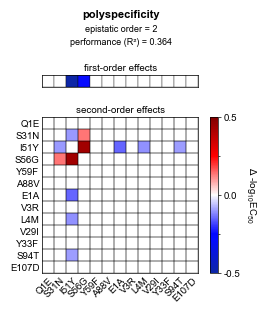

  Saved: S_Figure_6/psr_S_Figure_6.png
  Figure size: 2.755 × 3.180 in  |  canvas: 1.560 × 1.980 in

✅ Done!


In [3]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams.update({'axes.linewidth': 0.5,
    'xtick.major.size': 2, 'ytick.major.size': 2,
    'xtick.major.pad': 2, 'ytick.major.pad': 2})

OUTPUT_DIR = 'S_Figure_6'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# FILE PATHS
# ============================================================
PHENOTYPE_CONFIGS = {
    'wuhan_affinity': {'file_path': '../../epistasis_inference/linear_interaction_models/wuhan/reference-based/model_coeffs/wuhan_raw_2order_full_biochem.txt',           'order': 2, 'display_name': 'Wuhan affinity'},
    'ba1_affinity':   {'file_path': '../../epistasis_inference/linear_interaction_models/ba1/reference-based/model_coeffs/ba1_raw_3order_full_biochem.txt',               'order': 3, 'display_name': 'BA.1 affinity'},
    'ba4_affinity':   {'file_path': '../../epistasis_inference/linear_interaction_models/ba4/reference-based/model_coeffs/ba4_raw_3order_full_biochem.txt',               'order': 3, 'display_name': 'BA.4 affinity'},
    'expression':     {'file_path': '../../epistasis_inference/linear_interaction_models/expression/reference-based/model_coeffs/expression_raw_2order_full_biochem.txt', 'order': 2, 'display_name': 'expression'},
    'psr':            {'file_path': '../../epistasis_inference/linear_interaction_models/psr/reference-based/model_coeffs/psr_raw_2order_full_biochem.txt',               'order': 2, 'display_name': 'polyspecificity'},
}

# Phenotypes with order >= 3 get a higher-order panel
HIGHER_ORDER_PHENOTYPES = {'ba1_affinity', 'ba4_affinity'}

NUM_MUTATIONS = 13

CELL_SIZE = 0.12

LEFT_MARGIN          = 0.8
RIGHT_MARGIN         = 0.2
TOP_MARGIN           = 0.65   
BOTTOM_MARGIN        = 0.55

GAP_FIRST_TO_SECOND  = 0.3
GAP_SECOND_TO_HIGHER = 0.3

CBAR_PAD             = 0.12
CBAR_WIDTH           = 0.075
CBAR_GAP             = 0.4

CBAR_LABEL_PAD_SECOND = 12.5
CBAR_LABEL_PAD_HIGHER = 15

TITLE_X_2PANEL   = 0.575
TITLE_X_3PANEL   = 0.5
TITLE_Y_PAD      = 0.0

SUBTITLE_LINE1_PAD = 0.15   # epistatic order
SUBTITLE_LINE2_PAD = 0.28   # performance R²
SUBTITLE_LINE3_PAD = 0   # number of significant coefficients

XTICK_LABEL_OFFSET = 0.5

PHENOTYPE_PLOT_CONFIG = {
    'wuhan_affinity': {
        'first_vmin': -2.0,  'first_vmax': 2.0,
        'first_major_ticks': [-2, 0, 2],
        'first_minor_ticks': [-1, 1],
        'second_vmin': -2.0, 'second_vmax': 2.0,
        'second_major_ticks': [-2, 0, 2],
        'second_minor_ticks': [-1, 1],
        'cbar_label': r'$\Delta(-\log_{10} K_{\mathrm{D}})$',
        'tick_format': '{:.0f}',
    },
    'ba1_affinity': {
        'first_vmin': -2.0,  'first_vmax': 2.0,
        'first_major_ticks': [-2, 0, 2],
        'first_minor_ticks': [-1, 1],
        'second_vmin': -2.0, 'second_vmax': 2.0,
        'second_major_ticks': [-2, 0, 2],
        'second_minor_ticks': [-1, 1],
        'higher_vmin': 0,    'higher_vmax': 4.0,
        'higher_major_ticks': [0, 2, 4],
        'higher_minor_ticks': [1, 3],
        'cbar_label': r'$\Delta(-\log_{10} K_{\mathrm{D}})$',
        'higher_cbar_label': r'$\Sigma |\Delta(-\log_{10} K_{\mathrm{D}})|$',
        'tick_format': '{:.0f}',
    },
    'ba4_affinity': {
        'first_vmin': -2.0,  'first_vmax': 2.0,
        'first_major_ticks': [-2, 0, 2],
        'first_minor_ticks': [-1, 1],
        'second_vmin': -2.0, 'second_vmax': 2.0,
        'second_major_ticks': [-2, 0, 2],
        'second_minor_ticks': [-1, 1],
        'higher_vmin': 0,    'higher_vmax': 4.0,
        'higher_major_ticks': [0, 2, 4],
        'higher_minor_ticks': [1, 3],
        'cbar_label': r'$\Delta(-\log_{10} K_{\mathrm{D}})$',
        'higher_cbar_label': r'$\Sigma |\Delta(-\log_{10} K_{\mathrm{D}})|$',
        'tick_format': '{:.0f}',
    },
    'expression': {
        'first_vmin': -0.2,  'first_vmax': 0.2,
        'first_major_ticks': [-0.2, 0, 0.2],
        'first_minor_ticks': [-0.1, 0.1],
        'second_vmin': -0.2, 'second_vmax': 0.2,
        'second_major_ticks': [-0.2, 0, 0.2],
        'second_minor_ticks': [-0.1, 0.1],
        'cbar_label': r'Δ log$_{10}$ copy #$_{\mathit{app}}$',
        'tick_format': '{:.1f}',
    },
    'psr': {
        'first_vmin': -0.5,  'first_vmax': 0.5,
        'first_major_ticks': [-0.5, 0, 0.5],
        'first_minor_ticks': [-0.25, 0.25],
        'second_vmin': -0.5, 'second_vmax': 0.5,
        'second_major_ticks': [-0.5, 0, 0.5],
        'second_minor_ticks': [-0.25, 0.25],
        'cbar_label': r'$\Delta(-\log_{10} \mathit{EC}_{\mathrm{50}})$',
        'tick_format': '{:.1f}',
    },
}

def create_seismic_bright_blue():
    seismic = plt.colormaps['seismic']
    n = 256
    colors = seismic(np.linspace(0, 1, n))
    for i in range(int(n * 0.3)):
        pos = i / (n * 0.3)
        r, g, b, a = colors[i]
        bb = (1 - pos) * 0.5
        colors[i] = [min(1.0, r + bb*0.1), min(1.0, g + bb*0.3), min(1.0, b + bb*0.7), a]
    return LinearSegmentedColormap.from_list('seismic_bright_blue', colors)

def create_bright_purple_cmap():
    return LinearSegmentedColormap.from_list('bright_purple',
        ['#FFFFFF','#F3E5F5','#CE93D8','#AB47BC','#8E24AA','#6A1B9A'], N=256)

FIRST_SECOND_CMAP = create_seismic_bright_blue()
HIGHER_CMAP       = create_bright_purple_cmap()

def convert_mutation_label(label):
    match = re.match(r'([A-Z])(\d+)([A-Z])', label)
    if match:
        aa1, pos, aa2 = match.groups()
        return f'{aa1}{int(pos)-19}{aa2}'
    return label

# for mutation labels given in Tharp et al, 2026, subtract 19 from the position number for each mutation (for both heavy and light chain mutations)
ORIGINAL_MUTATION_LABELS = ['Q20E','S50N','I70Y','S75G','Y78F','A107V','E20A','V22R','L23M','V48I','Y52F','S113T','E126D']
MUTATION_LABELS = [convert_mutation_label(l) for l in ORIGINAL_MUTATION_LABELS]

def load_coefficients(filepath):
    if not os.path.exists(filepath):
        raise FileNotFoundError(filepath)
    names, coefs, sig = [], [], []
    with open(filepath, 'r') as f:
        reader = csv.reader(f, delimiter='\t')
        n_params   = int(next(reader)[1])
        r2         = float(next(reader)[1])
        alpha      = float(next(reader)[1])
        alpha_bonf = float(next(reader)[1])
        next(reader)
        for row in reader:
            if len(row) < 6: continue
            term, coef, se, pval, ci_l, ci_u = (
                row[0], float(row[1]), float(row[2]),
                float(row[3]), float(row[4]), float(row[5]))

            # Bonferroni: significant if p-value < alpha_bonf
            is_sig = (term != "Intercept" and pval < alpha_bonf)
            names.append(term); coefs.append(coef); sig.append(is_sig)
    return {'names': names, 'coefs': coefs, 'sig': sig, 'r2': r2}

def extract_effects(coef_data, num_mutations):
    first  = np.zeros(num_mutations)
    second = np.zeros((num_mutations, num_mutations))
    higher = np.zeros(num_mutations)
    for name, coef, is_sig in zip(coef_data['names'], coef_data['coefs'], coef_data['sig']):
        if not is_sig or name == 'Intercept': continue
        try: indices = [int(x) - 1 for x in name.split(',')]
        except: continue
        indices = [idx for idx in indices if 0 <= idx < num_mutations]
        if   len(indices) == 1:
            first[indices[0]] = coef
        elif len(indices) == 2:
            second[indices[0], indices[1]] = coef
            second[indices[1], indices[0]] = coef
        elif len(indices) >= 3:
            for idx in indices: higher[idx] += abs(coef)
    return first, second, higher

def add_colorbar(fig, ax_rect, sm, cfg, order, labelpad=None):
    cax  = fig.add_axes(ax_rect)
    cbar = fig.colorbar(sm, cax=cax)
    prefix = order + '_'
    major  = cfg[prefix + 'major_ticks']
    minor  = cfg.get(prefix + 'minor_ticks', [])
    label  = cfg.get(prefix + 'cbar_label', cfg['cbar_label'])
    fmt    = cfg.get('tick_format', '{:.2f}')
    if labelpad is None:
        labelpad = CBAR_LABEL_PAD_SECOND if order != 'higher' else CBAR_LABEL_PAD_HIGHER
    cbar.set_ticks(major)
    cbar.ax.yaxis.set_minor_locator(ticker.FixedLocator(minor))
    cbar.set_ticklabels([fmt.format(t) for t in major])
    cbar.ax.tick_params(which='major', labelsize=7, length=2, width=0.5, direction='out')
    cbar.ax.tick_params(which='minor', length=1.5, width=0.5, direction='out')
    cbar.set_label(label, fontsize=7, rotation=270, labelpad=labelpad)
    return cbar

def plot_phenotype(phenotype, pheno_data, mutation_labels, output_dir):
    cfg         = PHENOTYPE_PLOT_CONFIG[phenotype]
    first, second, higher = pheno_data['effects']
    display     = pheno_data['display_name']
    r2_val      = pheno_data['r2']
    n_sig       = pheno_data['n_sig']
    order_val   = pheno_data['order']
    has_higher  = phenotype in HIGHER_ORDER_PHENOTYPES
    N           = len(mutation_labels)

    h_first  = 1 * CELL_SIZE
    h_second = N * CELL_SIZE
    h_higher = CELL_SIZE if has_higher else 0
    canvas_w = N * CELL_SIZE

    canvas_h = (h_first + h_second + h_higher
                + GAP_FIRST_TO_SECOND
                + (GAP_SECOND_TO_HIGHER if has_higher else 0))

    fig_w = (LEFT_MARGIN + canvas_w + CBAR_PAD + CBAR_WIDTH
             + (CBAR_GAP + CBAR_WIDTH if has_higher else 0) + RIGHT_MARGIN)
    fig_h = TOP_MARGIN + canvas_h + BOTTOM_MARGIN

    fig = plt.figure(figsize=(fig_w, fig_h))

    title_x = TITLE_X_3PANEL if has_higher else TITLE_X_2PANEL

    fig.text(title_x, 1 - (TITLE_Y_PAD / fig_h),
             display,
             fontsize=8, fontweight='bold', ha='center', va='top',
             transform=fig.transFigure)

    fig.text(title_x, 1 - (SUBTITLE_LINE1_PAD / fig_h),
             f'epistatic order = {order_val}',
             fontsize=6.5, ha='center', va='top',
             transform=fig.transFigure)

    fig.text(title_x, 1 - (SUBTITLE_LINE2_PAD / fig_h),
             f'performance (R\u00b2) = {r2_val:.3f}',
             fontsize=6.5, ha='center', va='top',
             transform=fig.transFigure)

    def frac(inch, total): return inch / total

    if has_higher:
        bot_higher = frac(BOTTOM_MARGIN, fig_h)
        bot_second = frac(BOTTOM_MARGIN + h_higher + GAP_SECOND_TO_HIGHER, fig_h)
    else:
        bot_second = frac(BOTTOM_MARGIN, fig_h)

    bot_first = frac(BOTTOM_MARGIN
                     + h_higher + (GAP_SECOND_TO_HIGHER if has_higher else 0)
                     + h_second + GAP_FIRST_TO_SECOND, fig_h)

    ax_l    = frac(LEFT_MARGIN, fig_w)
    ax_w    = frac(canvas_w, fig_w)
    cbar_x  = frac(LEFT_MARGIN + canvas_w + CBAR_PAD, fig_w)
    cbar_x2 = frac(LEFT_MARGIN + canvas_w + CBAR_PAD + CBAR_WIDTH + CBAR_GAP, fig_w)
    cbar_w  = frac(CBAR_WIDTH, fig_w)

    h1_frac = frac(h_first, fig_h)
    ax1 = fig.add_axes([ax_l, bot_first, ax_w, h1_frac])
    for j, val in enumerate(first):
        color = ('white' if abs(val) < 1e-10 else
                 FIRST_SECOND_CMAP((np.clip(val, cfg['first_vmin'], cfg['first_vmax'])
                                    - cfg['first_vmin'])
                                   / (cfg['first_vmax'] - cfg['first_vmin'])))
        ax1.add_patch(patches.Rectangle((j, 0), 1, 1,
                      facecolor=color, edgecolor='black', linewidth=0.25))
    ax1.set_xlim(0, N); ax1.set_ylim(0, 1)
    ax1.set_xticks([]); ax1.set_yticks([])
    ax1.set_title('first-order effects', fontsize=7, pad=3)
    for sp in ax1.spines.values(): sp.set_linewidth(0.5)

    h2_frac = frac(h_second, fig_h)
    ax2 = fig.add_axes([ax_l, bot_second, ax_w, h2_frac])
    im2 = ax2.imshow(second, cmap=FIRST_SECOND_CMAP,
                     vmin=cfg['second_vmin'], vmax=cfg['second_vmax'],
                     aspect='equal', interpolation='nearest')
    for i in range(N):
        for j in range(N):
            if abs(second[i, j]) < 1e-10:
                ax2.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1,
                              facecolor='white', edgecolor='none'))
    for i in range(N):
        for j in range(N):
            ax2.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1,
                          facecolor='none', edgecolor='black', linewidth=0.25))

    show_x2 = not has_higher
    ax2.set_xticks(np.arange(N) + XTICK_LABEL_OFFSET)
    ax2.set_xticklabels(mutation_labels if show_x2 else [], fontsize=7, rotation=45, ha='right')
    ax2.set_yticks(np.arange(N))
    ax2.set_yticklabels(mutation_labels, fontsize=7)
    ax2.tick_params(axis='both', which='both', length=0, pad=2)
    ax2.set_title('second-order effects', fontsize=7, pad=3)
    for sp in ax2.spines.values(): sp.set_linewidth(0.5)

    sm2 = plt.cm.ScalarMappable(norm=Normalize(cfg['second_vmin'], cfg['second_vmax']),
                                 cmap=FIRST_SECOND_CMAP)
    add_colorbar(fig, [cbar_x, bot_second, cbar_w, h2_frac], sm2, cfg, 'second',
                 labelpad=CBAR_LABEL_PAD_SECOND)

    if has_higher:
        h3_frac = frac(h_higher, fig_h)
        ax3 = fig.add_axes([ax_l, bot_higher, ax_w, h3_frac])
        vmin_h = cfg.get('higher_vmin', 0)
        vmax_h = cfg.get('higher_vmax', 6)
        for j, val in enumerate(higher):
            color = ('white' if abs(val) < 1e-10 else
                     HIGHER_CMAP((np.clip(val, vmin_h, vmax_h) - vmin_h) / (vmax_h - vmin_h)))
            ax3.add_patch(patches.Rectangle((j, 0), 1, 1,
                          facecolor=color, edgecolor='black', linewidth=0.25))
        ax3.set_xlim(0, N); ax3.set_ylim(0, 1)
        ax3.set_xticks(np.arange(N) + 0.5 + XTICK_LABEL_OFFSET)
        ax3.set_xticklabels(mutation_labels, fontsize=7, rotation=45, ha='right')
        ax3.set_yticks([])
        ax3.tick_params(axis='x', which='both', length=0, pad=2)
        ax3.set_title('higher-order effects', fontsize=7, pad=3)
        for sp in ax3.spines.values(): sp.set_linewidth(0.5)

        sm3 = plt.cm.ScalarMappable(norm=Normalize(vmin_h, vmax_h), cmap=HIGHER_CMAP)
        add_colorbar(fig, [cbar_x2, bot_second, cbar_w, h2_frac], sm3, cfg, 'higher',
                     labelpad=CBAR_LABEL_PAD_HIGHER)

    out_png = os.path.join(output_dir, f'{phenotype}_S_Figure_6.png')

    fig.savefig(out_png, dpi=2000, bbox_inches='tight', transparent=True)

    plt.show()

    print(f"  Saved: {out_png}")
    print(f"  Figure size: {fig_w:.3f} × {fig_h:.3f} in  |  canvas: {canvas_w:.3f} × {canvas_h:.3f} in")
    plt.close(fig)

if __name__ == "__main__":
    print("=" * 60)
    print("Loading data and printing value ranges...")
    print("=" * 60)

    all_pheno_data = {}
    for key, cfg in PHENOTYPE_CONFIGS.items():
        try:
            coef_data = load_coefficients(cfg['file_path'])
            first, second, higher = extract_effects(coef_data, NUM_MUTATIONS)
            n_sig = sum(is_sig for name, is_sig in zip(coef_data['names'], coef_data['sig'])
                        if name != 'Intercept')
            all_pheno_data[key] = {
                'effects':      (first, second, higher),
                'r2':           coef_data['r2'],
                'n_sig':        n_sig,
                'display_name': cfg['display_name'],
                'order':        cfg['order'],
            }
            so_vals = second[second != 0]
            ho_vals = higher[higher != 0]
            print(f"\n{cfg['display_name']}  (R²={coef_data['r2']:.3f}, sig coefs={n_sig})")
            print(f"  First-order  range: [{first.min():.4f}, {first.max():.4f}]")
            print(f"  Second-order range: [{so_vals.min():.4f}, {so_vals.max():.4f}]"
                  if so_vals.size else "  Second-order: none")
            print(f"  Higher sums  range: [{ho_vals.min():.4f}, {ho_vals.max():.4f}]"
                  if ho_vals.size else "  Higher-order: none")
        except Exception as e:
            print(f"  ✗ {cfg['display_name']}: {e}")

    print("\n" + "=" * 60)
    print("Plotting (one figure per phenotype)...")
    print("=" * 60)
    for key, pheno_data in all_pheno_data.items():
        print(f"\n→ {pheno_data['display_name']}")
        plot_phenotype(key, pheno_data, MUTATION_LABELS, OUTPUT_DIR)

    print("\n✅ Done!")

**Supplemental Figure 7 - reference-free framework (all panels)**

Loading data and printing value ranges...

Wuhan affinity  (R²=0.814, sig coefs=30)
  First-order  range: [-0.0978, 0.4858]
  Second-order range: [-0.1035, 0.0694]
  Higher-order: none

BA.1 affinity  (R²=0.823, sig coefs=50)
  First-order  range: [-0.0706, 0.3822]
  Second-order range: [-0.1001, 0.0699]
  Higher sums  range: [0.0159, 0.3008]

BA.4 affinity  (R²=0.880, sig coefs=52)
  First-order  range: [-0.0642, 0.4475]
  Second-order range: [-0.0741, 0.0546]
  Higher sums  range: [0.0311, 0.4173]

expression  (R²=0.346, sig coefs=26)
  First-order  range: [-0.0399, 0.0304]
  Second-order range: [-0.0302, 0.0333]
  Higher-order: none

polyspecificity  (R²=0.364, sig coefs=10)
  First-order  range: [-0.2717, 0.0370]
  Second-order range: [-0.0378, 0.1074]
  Higher-order: none

Plotting (one figure per phenotype)...

→ Wuhan affinity


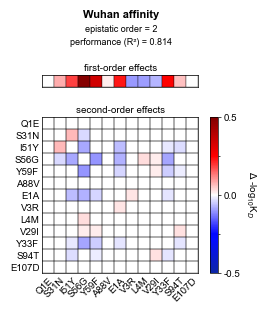

  Saved: S_Figure_7/wuhan_affinity_S_Figure_7.png
  Figure size: 2.755 × 3.180 in  |  canvas: 1.560 × 1.980 in

→ BA.1 affinity


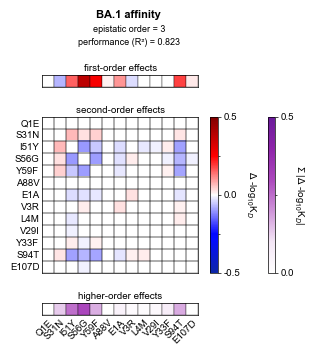

  Saved: S_Figure_7/ba1_affinity_S_Figure_7.png
  Figure size: 3.330 × 3.600 in  |  canvas: 1.560 × 2.400 in

→ BA.4 affinity


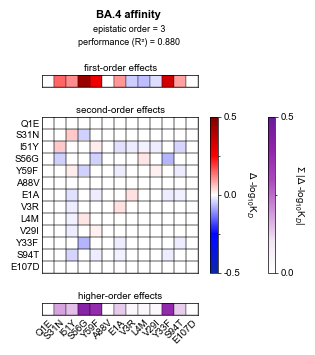

  Saved: S_Figure_7/ba4_affinity_S_Figure_7.png
  Figure size: 3.330 × 3.600 in  |  canvas: 1.560 × 2.400 in

→ expression


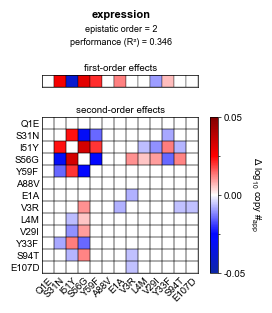

  Saved: S_Figure_7/expression_S_Figure_7.png
  Figure size: 2.755 × 3.180 in  |  canvas: 1.560 × 1.980 in

→ polyspecificity


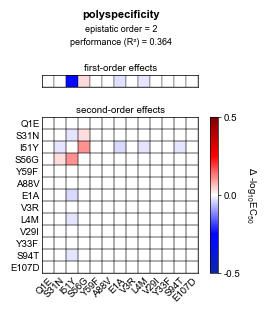

  Saved: S_Figure_7/psr_S_Figure_7.png
  Figure size: 2.755 × 3.180 in  |  canvas: 1.560 × 1.980 in

✅ Done!


In [6]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams.update({'axes.linewidth': 0.5,
    'xtick.major.size': 2, 'ytick.major.size': 2,
    'xtick.major.pad': 2, 'ytick.major.pad': 2})

OUTPUT_DIR = 'S_Figure_7'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PHENOTYPE_CONFIGS = {
    'wuhan_affinity': {'file_path': '../../epistasis_inference/linear_interaction_models/wuhan/reference-free/model_coeffs/wuhan_raw_2order_full_stat.txt',           'order': 2, 'display_name': 'Wuhan affinity'},
    'ba1_affinity':   {'file_path': '../../epistasis_inference/linear_interaction_models/ba1/reference-free/model_coeffs/ba1_raw_3order_full_stat.txt',               'order': 3, 'display_name': 'BA.1 affinity'},
    'ba4_affinity':   {'file_path': '../../epistasis_inference/linear_interaction_models/ba4/reference-free/model_coeffs/ba4_raw_3order_full_stat.txt',               'order': 3, 'display_name': 'BA.4 affinity'},
    'expression':     {'file_path': '../../epistasis_inference/linear_interaction_models/expression/reference-free/model_coeffs/expression_raw_2order_full_stat.txt', 'order': 2, 'display_name': 'expression'},
    'psr':            {'file_path': '../../epistasis_inference/linear_interaction_models/psr/reference-free/model_coeffs/psr_raw_2order_full_stat.txt',               'order': 2, 'display_name': 'polyspecificity'},
}

# Phenotypes with order >= 3 get a higher-order panel
HIGHER_ORDER_PHENOTYPES = {'ba1_affinity', 'ba4_affinity'}

NUM_MUTATIONS = 13

CELL_SIZE = 0.12        

LEFT_MARGIN          = 0.8    
RIGHT_MARGIN         = 0.2
TOP_MARGIN           = 0.65   
BOTTOM_MARGIN        = 0.55   

GAP_FIRST_TO_SECOND  = 0.3    
GAP_SECOND_TO_HIGHER = 0.3    

CBAR_PAD             = 0.12   
CBAR_WIDTH           = 0.075  
CBAR_GAP             = 0.5    #

CBAR_LABEL_PAD_SECOND = 12.5  
CBAR_LABEL_PAD_HIGHER = 8   

TITLE_X_2PANEL   = 0.575   
TITLE_X_3PANEL   = 0.5     
TITLE_Y_PAD      = 0.0    

SUBTITLE_LINE1_PAD = 0.15   
SUBTITLE_LINE2_PAD = 0.28   

XTICK_LABEL_OFFSET = 0.5

PHENOTYPE_PLOT_CONFIG = {
    'wuhan_affinity': {
        'first_vmin': -0.5,  'first_vmax': 0.5,
        'first_major_ticks': [-0.5, 0, 0.5],
        'first_minor_ticks': [-0.25, 0.25],
        'second_vmin': -0.5, 'second_vmax': 0.5,
        'second_major_ticks': [-0.5, 0, 0.5],
        'second_minor_ticks': [-0.25, 0.25],
        'cbar_label': r'$\Delta(-\log_{10} K_{\mathrm{D}})$',
        'tick_format': '{:.1f}',
    },
    'ba1_affinity': {
        'first_vmin': -0.5,  'first_vmax': 0.5,
        'first_major_ticks': [-0.5, 0, 0.5],
        'first_minor_ticks': [-0.25, 0.25],
        'second_vmin': -0.5, 'second_vmax': 0.5,
        'second_major_ticks': [-0.5, 0, 0.5],
        'second_minor_ticks': [-0.25, 0.25],
        'higher_vmin': 0,    'higher_vmax': 0.5,
        'higher_major_ticks': [0, 0.5],
        'higher_minor_ticks': [0.25],
        'cbar_label': r'$\Delta(-\log_{10} K_{\mathrm{D}})$',
        'higher_cbar_label': r'$\Sigma |\Delta(-\log_{10} K_{\mathrm{D}})|$',
        'tick_format': '{:.1f}',
    },
    'ba4_affinity': {
        'first_vmin': -0.5,  'first_vmax': 0.5,
        'first_major_ticks': [-0.5, 0, 0.5],
        'first_minor_ticks': [-0.25, 0.25],
        'second_vmin': -0.5, 'second_vmax': 0.5,
        'second_major_ticks': [-0.5, 0, 0.5],
        'second_minor_ticks': [-0.25, 0.25],
        'higher_vmin': 0,    'higher_vmax': 0.5,
        'higher_major_ticks': [0, 0.5],
        'higher_minor_ticks': [0.25],
        'cbar_label': r'$\Delta(-\log_{10} K_{\mathrm{D}})$',
        'higher_cbar_label': r'$\Sigma |\Delta(-\log_{10} K_{\mathrm{D}})|$',
        'tick_format': '{:.1f}',
    },
    'expression': {
        'first_vmin': -0.05,  'first_vmax': 0.05,
        'first_major_ticks': [-0.05, 0, 0.05],
        'first_minor_ticks': [-0.025, 0.025],
        'second_vmin': -0.05, 'second_vmax': 0.05,
        'second_major_ticks': [-0.05, 0, 0.05],
        'second_minor_ticks': [-0.025, 0.025],
        'cbar_label': r'Δ log$_{10}$ copy #$_{\mathit{app}}$',
        'tick_format': '{:.2f}',
    },
    'psr': {
        'first_vmin': -0.5,  'first_vmax': 0.5,
        'first_major_ticks': [-0.5, 0, 0.5],
        'first_minor_ticks': [-0.25, 0.25],
        'second_vmin': -0.5, 'second_vmax': 0.5,
        'second_major_ticks': [-0.5, 0, 0.5],
        'second_minor_ticks': [-0.5, 0.5],
        'cbar_label': r'$\Delta(-\log_{10} \mathit{EC}_{\mathrm{50}})$',
        'tick_format': '{:.1f}',
    },
}

def create_seismic_bright_blue():
    seismic = plt.colormaps['seismic']
    n = 256
    colors = seismic(np.linspace(0, 1, n))
    for i in range(int(n * 0.3)):
        pos = i / (n * 0.3)
        r, g, b, a = colors[i]
        bb = (1 - pos) * 0.5
        colors[i] = [min(1.0, r + bb*0.1), min(1.0, g + bb*0.3), min(1.0, b + bb*0.7), a]
    return LinearSegmentedColormap.from_list('seismic_bright_blue', colors)

def create_bright_purple_cmap():
    return LinearSegmentedColormap.from_list('bright_purple',
        ['#FFFFFF','#F3E5F5','#CE93D8','#AB47BC','#8E24AA','#6A1B9A'], N=256)

FIRST_SECOND_CMAP = create_seismic_bright_blue()
HIGHER_CMAP       = create_bright_purple_cmap()

def convert_mutation_label(label):
    match = re.match(r'([A-Z])(\d+)([A-Z])', label)
    if match:
        aa1, pos, aa2 = match.groups()
        return f'{aa1}{int(pos)-19}{aa2}'
    return label

# for mutation labels given in Tharp et al, 2026, subtract 19 from the position number for each mutation (for both heavy and light chain mutations)
ORIGINAL_MUTATION_LABELS = ['Q20E','S50N','I70Y','S75G','Y78F','A107V','E20A','V22R','L23M','V48I','Y52F','S113T','E126D']
MUTATION_LABELS = [convert_mutation_label(l) for l in ORIGINAL_MUTATION_LABELS]

def load_coefficients(filepath):
    if not os.path.exists(filepath):
        raise FileNotFoundError(filepath)
    names, coefs, sig = [], [], []
    with open(filepath, 'r') as f:
        reader = csv.reader(f, delimiter='\t')
        n_params   = int(next(reader)[1])
        r2         = float(next(reader)[1])
        alpha      = float(next(reader)[1])
        alpha_bonf = float(next(reader)[1])
        next(reader)
        for row in reader:
            if len(row) < 6: continue
            term, coef, se, pval, ci_l, ci_u = (
                row[0], float(row[1]), float(row[2]),
                float(row[3]), float(row[4]), float(row[5]))

            # Bonferroni: significant if p-value < alpha_bonf
            is_sig = (term != "Intercept" and pval < alpha_bonf)
            names.append(term); coefs.append(coef); sig.append(is_sig)
    return {'names': names, 'coefs': coefs, 'sig': sig, 'r2': r2}

def extract_effects(coef_data, num_mutations):
    first  = np.zeros(num_mutations)
    second = np.zeros((num_mutations, num_mutations))
    higher = np.zeros(num_mutations)
    for name, coef, is_sig in zip(coef_data['names'], coef_data['coefs'], coef_data['sig']):
        if not is_sig or name == 'Intercept': continue
        try: indices = [int(x) - 1 for x in name.split(',')]
        except: continue
        indices = [idx for idx in indices if 0 <= idx < num_mutations]
        if   len(indices) == 1:
            first[indices[0]] = coef
        elif len(indices) == 2:
            second[indices[0], indices[1]] = coef
            second[indices[1], indices[0]] = coef
        elif len(indices) >= 3:
            for idx in indices: higher[idx] += abs(coef)
    return first, second, higher

def add_colorbar(fig, ax_rect, sm, cfg, order, labelpad=None):
    """ax_rect = [left, bottom, width, height] in figure fractions."""
    cax  = fig.add_axes(ax_rect)
    cbar = fig.colorbar(sm, cax=cax)
    prefix = order + '_'
    major  = cfg[prefix + 'major_ticks']
    minor  = cfg.get(prefix + 'minor_ticks', [])
    label  = cfg.get(prefix + 'cbar_label', cfg['cbar_label'])
    fmt    = cfg.get('tick_format', '{:.2f}')
    if labelpad is None:
        labelpad = CBAR_LABEL_PAD_SECOND if order != 'higher' else CBAR_LABEL_PAD_HIGHER
    cbar.set_ticks(major)
    cbar.ax.yaxis.set_minor_locator(ticker.FixedLocator(minor))
    cbar.set_ticklabels([fmt.format(t) for t in major])
    cbar.ax.tick_params(which='major', labelsize=7, length=2, width=0.5, direction='out')
    cbar.ax.tick_params(which='minor', length=1.5, width=0.5, direction='out')
    cbar.set_label(label, fontsize=7, rotation=270, labelpad=labelpad)
    return cbar

def plot_phenotype(phenotype, pheno_data, mutation_labels, output_dir):
    cfg         = PHENOTYPE_PLOT_CONFIG[phenotype]
    first, second, higher = pheno_data['effects']
    display     = pheno_data['display_name']
    r2_val      = pheno_data['r2']
    order_val   = pheno_data['order']
    n_sig       = pheno_data['n_sig']
    has_higher  = phenotype in HIGHER_ORDER_PHENOTYPES
    N           = len(mutation_labels)

    h_first  = 1 * CELL_SIZE
    h_second = N * CELL_SIZE
    h_higher = CELL_SIZE if has_higher else 0
    canvas_w = N * CELL_SIZE

    canvas_h = h_first + h_second + h_higher + GAP_FIRST_TO_SECOND + (GAP_SECOND_TO_HIGHER if has_higher else 0)

    fig_w = LEFT_MARGIN + canvas_w + CBAR_PAD + CBAR_WIDTH + (CBAR_GAP + CBAR_WIDTH if has_higher else 0) + RIGHT_MARGIN
    fig_h = TOP_MARGIN  + canvas_h + BOTTOM_MARGIN

    fig = plt.figure(figsize=(fig_w, fig_h))

    title_x = TITLE_X_3PANEL if has_higher else TITLE_X_2PANEL

    fig.text(title_x, 1 - (TITLE_Y_PAD / fig_h),
             display,
             fontsize=8, fontweight='bold', ha='center', va='top',
             transform=fig.transFigure)

    fig.text(title_x, 1 - (SUBTITLE_LINE1_PAD / fig_h),
             f'epistatic order = {order_val}',
             fontsize=6.5, ha='center', va='top',
             transform=fig.transFigure)

    fig.text(title_x, 1 - (SUBTITLE_LINE2_PAD / fig_h),
             f'performance (R\u00b2) = {r2_val:.3f}',
             fontsize=6.5, ha='center', va='top',
             transform=fig.transFigure)

    def frac(inch, total): return inch / total

    if has_higher:
        bot_higher = frac(BOTTOM_MARGIN, fig_h)
        bot_second = frac(BOTTOM_MARGIN + h_higher + GAP_SECOND_TO_HIGHER, fig_h)
    else:
        bot_second = frac(BOTTOM_MARGIN, fig_h)

    bot_first = frac(BOTTOM_MARGIN
                     + h_higher + (GAP_SECOND_TO_HIGHER if has_higher else 0)
                     + h_second + GAP_FIRST_TO_SECOND, fig_h)

    ax_l    = frac(LEFT_MARGIN, fig_w)
    ax_w    = frac(canvas_w, fig_w)
    cbar_x  = frac(LEFT_MARGIN + canvas_w + CBAR_PAD, fig_w)
    cbar_x2 = frac(LEFT_MARGIN + canvas_w + CBAR_PAD + CBAR_WIDTH + CBAR_GAP, fig_w)
    cbar_w  = frac(CBAR_WIDTH, fig_w)

    h1_frac = frac(h_first, fig_h)
    ax1 = fig.add_axes([ax_l, bot_first, ax_w, h1_frac])
    for j, val in enumerate(first):
        color = ('white' if abs(val) < 1e-10 else
                 FIRST_SECOND_CMAP((np.clip(val, cfg['first_vmin'], cfg['first_vmax'])
                                    - cfg['first_vmin'])
                                   / (cfg['first_vmax'] - cfg['first_vmin'])))
        ax1.add_patch(patches.Rectangle((j, 0), 1, 1,
                      facecolor=color, edgecolor='black', linewidth=0.25))
    ax1.set_xlim(0, N); ax1.set_ylim(0, 1)
    ax1.set_xticks([]); ax1.set_yticks([])
    ax1.set_title('first-order effects', fontsize=7, pad=3)
    for sp in ax1.spines.values(): sp.set_linewidth(0.5)

    h2_frac = frac(h_second, fig_h)
    ax2 = fig.add_axes([ax_l, bot_second, ax_w, h2_frac])
    im2 = ax2.imshow(second, cmap=FIRST_SECOND_CMAP,
                     vmin=cfg['second_vmin'], vmax=cfg['second_vmax'],
                     aspect='equal', interpolation='nearest')
    for i in range(N):
        for j in range(N):
            if abs(second[i, j]) < 1e-10:
                ax2.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1,
                              facecolor='white', edgecolor='none'))

    for i in range(N):
        for j in range(N):
            ax2.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1,
                          facecolor='none', edgecolor='black', linewidth=0.25))

    show_x2 = not has_higher
    ax2.set_xticks(np.arange(N) + XTICK_LABEL_OFFSET)
    ax2.set_xticklabels(mutation_labels if show_x2 else [], fontsize=7, rotation=45, ha='right')
    ax2.set_yticks(np.arange(N))
    ax2.set_yticklabels(mutation_labels, fontsize=7)
    ax2.tick_params(axis='both', which='both', length=0, pad=2)
    ax2.set_title('second-order effects', fontsize=7, pad=3)
    for sp in ax2.spines.values(): sp.set_linewidth(0.5)

    sm2 = plt.cm.ScalarMappable(norm=Normalize(cfg['second_vmin'], cfg['second_vmax']),
                                 cmap=FIRST_SECOND_CMAP)
    add_colorbar(fig, [cbar_x, bot_second, cbar_w, h2_frac], sm2, cfg, 'second',
                 labelpad=CBAR_LABEL_PAD_SECOND)

    if has_higher:
        h3_frac = frac(h_higher, fig_h)
        ax3 = fig.add_axes([ax_l, bot_higher, ax_w, h3_frac])
        vmin_h = cfg.get('higher_vmin', 0)
        vmax_h = cfg.get('higher_vmax', 6)
        for j, val in enumerate(higher):
            color = ('white' if abs(val) < 1e-10 else
                     HIGHER_CMAP((np.clip(val, vmin_h, vmax_h) - vmin_h) / (vmax_h - vmin_h)))
            ax3.add_patch(patches.Rectangle((j, 0), 1, 1,
                          facecolor=color, edgecolor='black', linewidth=0.25))
        ax3.set_xlim(0, N); ax3.set_ylim(0, 1)
        ax3.set_xticks(np.arange(N) + 0.5 + XTICK_LABEL_OFFSET)
        ax3.set_xticklabels(mutation_labels, fontsize=7, rotation=45, ha='right')
        ax3.set_yticks([])
        ax3.tick_params(axis='x', which='both', length=0, pad=2)
        ax3.set_title('higher-order effects', fontsize=7, pad=3)
        for sp in ax3.spines.values(): sp.set_linewidth(0.5)

        sm3 = plt.cm.ScalarMappable(norm=Normalize(vmin_h, vmax_h), cmap=HIGHER_CMAP)
        add_colorbar(fig, [cbar_x2, bot_second, cbar_w, h2_frac], sm3, cfg, 'higher',
                     labelpad=CBAR_LABEL_PAD_HIGHER)

    out_png = os.path.join(output_dir, f'{phenotype}_S_Figure_7.png')

    fig.savefig(out_png, dpi=2000, bbox_inches='tight', transparent=True)

    plt.show()

    print(f"  Saved: {out_png}")
    print(f"  Figure size: {fig_w:.3f} × {fig_h:.3f} in  |  canvas: {canvas_w:.3f} × {canvas_h:.3f} in")
    plt.close(fig)

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Loading data and printing value ranges...")
    print("=" * 60)

    all_pheno_data = {}
    for key, cfg in PHENOTYPE_CONFIGS.items():
        try:
            coef_data = load_coefficients(cfg['file_path'])
            first, second, higher = extract_effects(coef_data, NUM_MUTATIONS)
            n_sig = sum(is_sig for name, is_sig in zip(coef_data['names'], coef_data['sig'])
                        if name != 'Intercept')
            all_pheno_data[key] = {
                'effects':      (first, second, higher),
                'r2':           coef_data['r2'],
                'n_sig':        n_sig,
                'display_name': cfg['display_name'],
                'order':        cfg['order'],
            }
            so_vals = second[second != 0]
            ho_vals = higher[higher != 0]
            print(f"\n{cfg['display_name']}  (R²={coef_data['r2']:.3f}, sig coefs={n_sig})")
            print(f"  First-order  range: [{first.min():.4f}, {first.max():.4f}]")
            print(f"  Second-order range: [{so_vals.min():.4f}, {so_vals.max():.4f}]"
                  if so_vals.size else "  Second-order: none")
            print(f"  Higher sums  range: [{ho_vals.min():.4f}, {ho_vals.max():.4f}]"
                  if ho_vals.size else "  Higher-order: none")
        except Exception as e:
            print(f"  ✗ {cfg['display_name']}: {e}")

    print("\n" + "=" * 60)
    print("Plotting (one figure per phenotype)...")
    print("=" * 60)
    for key, pheno_data in all_pheno_data.items():
        print(f"\n→ {pheno_data['display_name']}")
        plot_phenotype(key, pheno_data, MUTATION_LABELS, OUTPUT_DIR)

    print("\n✅ Done!")